<a href="https://colab.research.google.com/github/NMelbard/PBL1/blob/main/PBL_1_amoxicillin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

There are three compartments of relevance.

in the gut: input - (absorbed into blood) - (fecal waste)<br>
in the blood: (absorbed into blood) - (renal waste) - decay - (absorbed into lung) + (lung back to blood)<br>
in the lung: (absorbed into lung) - (lung back to blood)

In [35]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [36]:
#constants

F = 0.85
alpha = 1.02 #rate constant for gut to blood absorption
w = 0.66 #amount expelled as waste renally
beta = 0.92 #rate constant for blood to lung absorption
gamma = 1.99 #rate constant for lung back to blood absorption

V_gut = 0.44
V_blood = 17.23
V_lung = 2.53

alpha, w, beta, gamma parameters estimated from [1]


the volume of distribution is approximately 20.2 L.
approximately 2.20% of the body's blood is in the large intestine. [2]
approximately 12.50% of the blood is in the lungs. [2]
assume rest is V_blood.

"Pharmacokinetic parameters of amoxicillin were studied in healthy fasted subjects afqer both oral and intravenous administration of a single 500-mg dose. Serum levels and urinary excretion rates were determined at various time intervals by a microbiological method. The conventional two-compartment model with elimination occurring from the central compartment was used to analyze the data. Mean values were 3.40 h-1 for alpha and 0.68 h-1 for beta. Distribution constants kappa 12 and kappa 21 were 0.92 h-1 and 1.99 h-1, respectively. The rate constant for elimination from the central compartment, kappa 10, was 1.16 h-1. The volume of distribution was 20.2 liters (0.30 liter/kg), and the serum clearance was 13.3 liters/h. The absorption rate constant, kappa a, in the oral study, calculated by the Loo-Riegelman method, was 1.02 h-1, and the absorption half-life was 0.72 h. Absolute bioavailability after the oral dose was determined by comparing both the areas under the curve (AUC) and fractions of the antibiotic excreted unchanged in the urine. The AUC after oral administration was 77.4% of the intravenous AUC. On the other hand, recovery from the urine was 43.4% after the oral dose and 57.4% after the intravenous dose, indicating 76.5% bioavailability."[1]

[1]Arancibia, A., Guttmann, J., González, G., & González, C. (1980). Absorption and disposition kinetics of amoxicillin in normal human subjects. Antimicrobial agents and chemotherapy, 17(2), 199–202. https://doi.org/10.1128/AAC.17.2.199

[2]Wayson, M. B., Leggett, R. W., Jokisch, D. W., Lee, C., Schwarz, B. C., Godwin, W. J., & Bolch, W. E. (2018). Suggested reference values for regional blood volumes in children and adolescents. Physics in medicine and biology, 63(15), 155022. https://doi.org/10.1088/1361-6560/aad313


In [37]:
import math

def A_input(t):
  if math.floor(t) % 8 == 0: #every 8 hours the patient takes the medication.
    return 500
  else:
    return 0

def f_amx(t, y, c):
  """
  c = [alpha, w, beta, gamma]
  """
  a_gut, a_blood, a_lung = y

  dagdt = A_input(t)/V_gut - c[0]*a_gut #gut
  dabdt = F*c[0]*a_gut*(V_gut/V_blood) - c[1]*a_blood - c[2]*a_blood + c[3]*a_lung*(V_lung/V_blood) #blood
  daldt = c[2]*a_blood*(V_blood/V_lung) - c[3]*a_lung #lung

  return [dagdt, dabdt, daldt]

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.805e-02 ...  4.795e+01  4.800e+01]
        y: [[ 0.000e+00  5.328e+01 ...  5.427e-01  5.190e-01]
            [ 0.000e+00  2.787e-02 ...  1.037e+00  1.017e+00]
            [ 0.000e+00  2.759e-03 ...  4.107e+00  4.027e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1058
     njev: 0
      nlu: 0


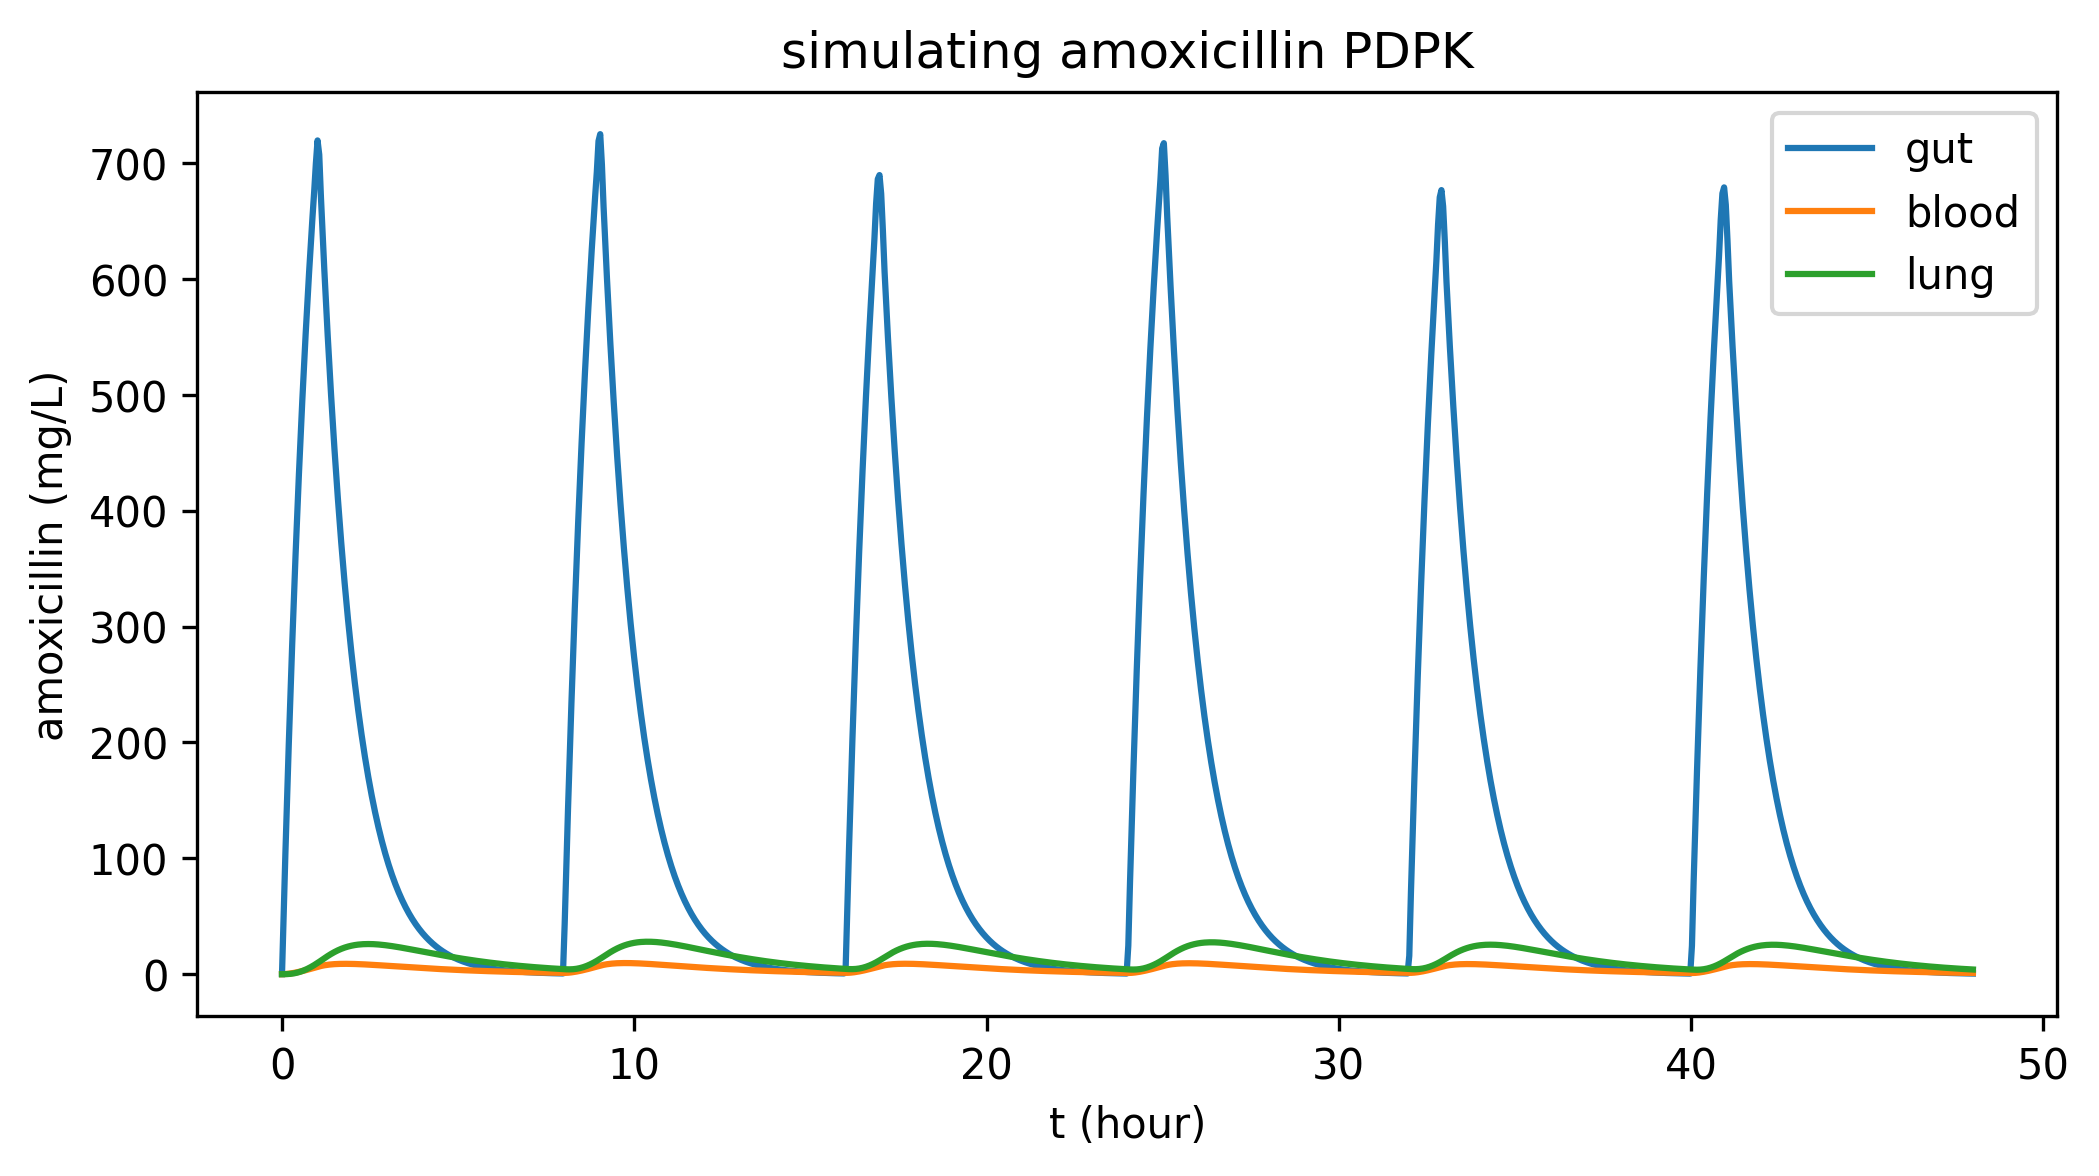

In [40]:
c = [alpha, w, beta, gamma]
yinit = [0, 0, 0]

tspan = np.linspace(0, 48, 1000)

sol = solve_ivp(lambda t, y: f_amx(t,y,c), [tspan[0], tspan[-1]], yinit, t_eval=tspan)
print(sol)

plt.figure(figsize=(8,4),dpi=300)
plt.plot(sol.t, sol.y[0], label='gut')
plt.plot(sol.t, sol.y[1], label='blood')
plt.plot(sol.t, sol.y[2], label='lung')
plt.xlabel('t (hour)')
plt.ylabel('amoxicillin (mg/L)')
plt.legend()
plt.title('simulating amoxicillin PDPK')
plt.show()

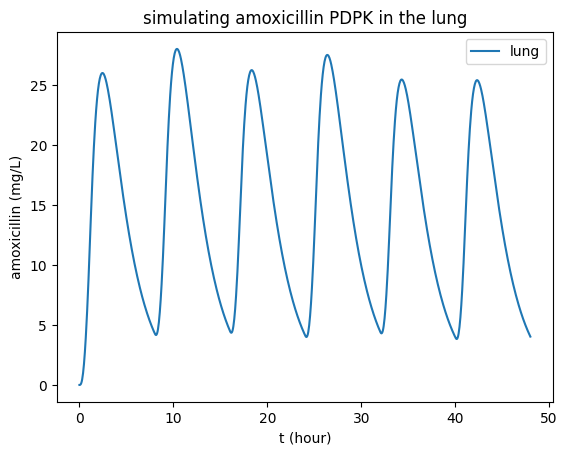

In [41]:
plt.plot(sol.t, sol.y[2], label='lung')
plt.xlabel('t (hour)')
plt.ylabel('amoxicillin (mg/L)')
plt.legend()
plt.title('simulating amoxicillin PDPK in the lung')
plt.show()